In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from matplotlib.patches import Patch

import analysis_utils as base

set_size = base.set_size
pgf_with_latex = base.pgf_with_latex
doc_width_pt = base.doc_width_pt

plt.rcParams.update(pgf_with_latex)

sns.set_palette("colorblind")

## Compute time vs. instance hardness (lightsout-5x4)

Loads a trained `lightsout-5x4` checkpoint (Transformer implicit-CoT actor, adaptive
compute budget), rolls it out on fresh instances sampled from the *training*
distribution ("trained instances" - `eval=False`, easy/in-distribution goals, as
opposed to `LightsOutEnv`'s held-out hard eval goals), and for each episode records:

- the initial grid and goal grid at reset,
- the puzzle's true shortest-path length between them (the minimum number of button
  presses needed - solved exactly over GF(2), *not* the `dist` used to generate the
  goal, which need not be minimal if `LightsOutEnv`'s toggle matrix has a nontrivial
  kernel),
- the actor's realised compute time (pondering steps), averaged per action over the
  episode, matching `stoix.systems.ramdp_vpg.evaluator`'s convention.

It then looks at whether harder instances (longer shortest path) get more compute.

**Before running:** fill in `CHECKPOINT_REL_DIR`/`CHECKPOINT_UID` (and
`CHECKPOINT_MODEL_NAME` if not the default) in the config cell below once a trained
`lightsout-5x4` checkpoint is available - none is saved locally in this repo
(`save_model` is off by default; these runs were launched on the cluster - see
`ramdp_experiments/slurm/lightsout-icot.sh`). The network hyperparameters
(`HIDDEN_DIM`, `NUM_LAYERS`, ...) must exactly match the checkpoint's training run,
or `Checkpointer.restore_params` will fail on a param-shape mismatch - the defaults
here match that slurm script's `lightsout-5x4` Transformer-CoT/reinforce/adaptive[1-5]
command.

In [2]:
import os
import sys
from pathlib import Path

# Hydra's `hydra.searchpath` for stoix's configs (`file://stoix/configs`) is
# relative to cwd, so run everything from the repo root - matching how
# lightsout_sweep.py/ff_ppo.py are always invoked.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "ramdp_experiments" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import hydra
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from stoa.utility_wrappers.extras_transforms import NoExtrasWrapper

from stoix.base_types import ActorCriticParams
from stoix.envs.lightsout.lightsout_env import LightsOutEnv
from stoix.envs.lightsout.lightsout_env import default_config as lightsout_default_config
from stoix.networks.base import FeedForwardCritic
from stoix.networks.base_compute import FeedForwardActorWithComputeTime as Actor
from stoix.systems.ramdp_vpg.ff_reinforce import get_distribution_act_fn_with_compute_time
from stoix.utils import make_env as environments
from stoix.utils.checkpointing import Checkpointer

from tqdm.notebook import tqdm

In [3]:
# --- Checkpoint - fill in once a trained lightsout-5x4 checkpoint is available.
# These three map directly onto config.logger.checkpointing.load_args (rel_dir,
# checkpoint_uid) and model_name=config.system.system_name, i.e. exactly the knobs
# `learner_setup` itself uses to restore a checkpoint - see stoix/utils/checkpointing.py.
CHECKPOINT_REL_DIR = "/home/bryanpu1/projects/iclr_2027/Stoix/ramdp_experiments/checkpoints"  # e.g. "/path/to/run_dir/checkpoints" (absolute path is fine)
CHECKPOINT_UID = "20260923032800"  # e.g. "20260101120000"
CHECKPOINT_MODEL_NAME = "ramdp_ff_ppo"  # config.system.system_name default for ff_ppo.py

# Skips the checkpoint restore entirely and rolls out the freshly-initialized
# (untrained) actor instead - lets the rest of the pipeline (env, GF(2) solver,
# rollout loop, analysis/plot) be smoke-tested without a trained checkpoint. A
# random policy has no reason to spend more compute on harder instances, so
# expect ~0 correlation - this only tests that the code runs end-to-end, not
# that the trained agent behaves sensibly.
USE_RANDOM_POLICY = False

# --- Env ---
GRID_SIZE = "5x4"
EPISODE_LENGTH = 10
EVAL_EPISODE_LENGTH = 20
DIFFICULTY_THRESHOLD = 0.5
# "Trained instances" = the training distribution (eval=False, easy/in-distribution
# goals - see LightsOutEnv's module docstring). Flip to True for the held-out hard
# eval instances instead.
EVAL_HARD_INSTANCES = True

# --- Network: Transformer implicit-CoT, adaptive compute budget. Must exactly match
# the checkpoint's training run (see the intro markdown cell). Defaults below are
# lightsout-5x4's Transformer-CoT/reinforce/adaptive[1-5] run (see
# ramdp_experiments/slurm/lightsout-icot.sh's active command).
HIDDEN_DIM = 128
NUM_LAYERS = 2
NUM_HEADS = 8
MLP_DIM = 256
QKV_DIM = 256
MIN_STEPS = 1
MAX_STEPS = 5
HALTING_TEMPERATURE = 5.0
USE_INPUT_LAYER_NORM = True
USE_SANDWICH_NORM = False
USE_RMSNORM = True
STOP_GRADIENT_HALTING_INPUT = False
QAC_VARIANT = "reinforce"  # plain V-only critic - must match qac_variant used to train the checkpoint

# --- Rollout ---
NUM_EVAL_EPISODES = 10000
SEED = 0
EVALUATION_GREEDY = False  # match training-time stochastic policy; True evaluates the mode action instead
# rollout_episodes re-JITs and re-runs NUM_EVAL_EPISODES full episodes every time the
# rollout cell executes, which is slow - once a rollout has run, its dataframe is
# cached to ROLLOUT_CACHE_PATH (see below) and reloaded from there on subsequent runs
# instead of being recomputed. Set True to ignore any cache and force a fresh rollout
# (e.g. after changing the checkpoint or network hyperparameters above without also
# changing NUM_EVAL_EPISODES/SEED, which the cache path does not otherwise capture).
FORCE_REROLLOUT = True

In [4]:
def build_stoix_config():
    """Composes the same DictConfig ff_ppo.py's @hydra.main would build for a
    lightsout-5x4 / transformer_compute run, via the CLI overrides
    ramdp_experiments/lightsout_sweep.py's Job.command() would emit for this
    (system=ff_ppo_reinforce, architecture=transformer) combo."""
    overrides = [
        # Base env config is a fixed 3x3 example - grid size/task name/episode
        # length are overridden below, same as Job.command().
        "env=lightsout/lightsout_3x3",
        f"env.scenario.name=lightsout-{GRID_SIZE}",
        f"env.scenario.task_name=lightsout_{GRID_SIZE}",
        f"env.kwargs.episode_length={EPISODE_LENGTH}",
        f"++env.kwargs.eval_episode_length={EVAL_EPISODE_LENGTH}",
        f"env.kwargs.difficulty_threshold={DIFFICULTY_THRESHOLD}",
        # LightsOutEnv's native (m, n, 2) observation is flattened for non-CNN
        # torsos (transformer_compute has no CNN input_layer) - see
        # lightsout_sweep.py's Job.command().
        "+env.wrapper._target_=stoa.FlattenObservationWrapper",
        "network=transformer_compute",
        f"network.actor_network.pre_torso.hidden_dim={HIDDEN_DIM}",
        f"++network.actor_network.pre_torso.num_layers={NUM_LAYERS}",
        f"++network.actor_network.pre_torso.num_heads={NUM_HEADS}",
        f"++network.actor_network.pre_torso.mlp_dim={MLP_DIM}",
        f"++network.actor_network.pre_torso.qkv_dim={QKV_DIM}",
        f"network.actor_network.pre_torso.min_steps={MIN_STEPS}",
        f"network.actor_network.pre_torso.max_steps={MAX_STEPS}",
        f"network.actor_network.pre_torso.halting_temperature={HALTING_TEMPERATURE}",
        f"++network.actor_network.pre_torso.use_input_layer_norm={USE_INPUT_LAYER_NORM}",
        f"++network.actor_network.pre_torso.use_sandwich_norm={USE_SANDWICH_NORM}",
        f"++network.actor_network.pre_torso.use_rmsnorm={USE_RMSNORM}",
        f"++network.actor_network.pre_torso.stop_gradient_halting_input={STOP_GRADIENT_HALTING_INPUT}",
        f"system.qac_variant={QAC_VARIANT}",
        f"arch.evaluation_greedy={EVALUATION_GREEDY}",
    ]
    GlobalHydra.instance().clear()
    with initialize_config_dir(
        config_dir=str(REPO_ROOT / "stoix/configs/default/anakin"), version_base=None
    ):
        config = compose(config_name="default_ramdp_ff_ppo.yaml", overrides=overrides)
    return config


config = build_stoix_config()

In [5]:
def build_actor_and_restore(config, seed=0):
    """Mirrors the actor/critic construction in
    stoix.systems.ramdp_vpg.ff_ppo.learner_setup (skipping the
    optimizer/learner_fn machinery, which pure inference doesn't need), then
    either restores the actor's trained params from CHECKPOINT_REL_DIR/UID or,
    if USE_RANDOM_POLICY, returns the freshly-initialized params as-is. Returns
    (env, eval_env, act_fn, actor_params). `env` is `environments.make()`'s
    vmapped/auto-reset training env (used below only for its action_space) -
    it is NOT suitable for the single-episode rollout loop, see
    build_train_instances_env."""
    assert USE_RANDOM_POLICY or CHECKPOINT_UID is not None, (
        "Fill in CHECKPOINT_REL_DIR/CHECKPOINT_UID in the config cell before running this "
        "(or set USE_RANDOM_POLICY=True to smoke-test the pipeline without one)."
    )

    env, eval_env = environments.make(config=config)
    num_actions = int(env.action_space().num_values)

    key = jax.random.PRNGKey(seed)
    actor_net_key, critic_net_key = jax.random.split(key)

    actor_torso = hydra.utils.instantiate(config.network.actor_network.pre_torso)
    actor_action_head = hydra.utils.instantiate(
        config.network.actor_network.action_head, action_dim=num_actions
    )
    actor_network = Actor(torso=actor_torso, action_head=actor_action_head)

    init_x = eval_env.observation_space().generate_value()
    init_x = jax.tree_util.tree_map(lambda x: x[None, ...], init_x)
    actor_params = actor_network.init(actor_net_key, init_x, torso_kwargs={"rng": actor_net_key})

    if not USE_RANDOM_POLICY:
        # QAC_VARIANT="reinforce" -> plain V-only critic (FeedForwardCritic), matching
        # ff_ppo.py's learner_setup. The critic is only needed to reconstruct the
        # checkpoint's full ActorCriticParams structure for Checkpointer.restore_params -
        # its params are discarded below, since rollouts here only use the actor.
        critic_torso = hydra.utils.instantiate(config.network.critic_network.pre_torso)
        critic_head = hydra.utils.instantiate(config.network.critic_network.critic_head)
        critic_network = FeedForwardCritic(torso=critic_torso, critic_head=critic_head)
        critic_params = critic_network.init(critic_net_key, init_x)
        params = ActorCriticParams(actor_params, critic_params)

        loaded_checkpoint = Checkpointer(
            model_name=CHECKPOINT_MODEL_NAME,
            rel_dir=CHECKPOINT_REL_DIR or "checkpoints",
            checkpoint_uid=CHECKPOINT_UID,
        )
        restored_params, _ = loaded_checkpoint.restore_params(input_params=params)
        actor_params = restored_params.actor_params

    act_fn = get_distribution_act_fn_with_compute_time(config, actor_network.apply)
    return env, eval_env, act_fn, actor_params


def build_train_instances_env(config):
    """A single, un-batched LightsOut env sampling the *training* distribution
    (eval=False, easy/in-distribution goals) - the un-batched counterpart to
    `environments.make()`'s `env`.

    `environments.make()`'s `env` (see `stoix.utils.make_env.make_lightsout_env`)
    is wrapped with AddRNGKey/AutoResetWrapper/VmapWrapper (`apply_core_wrappers`)
    for the vectorized training loop, so it expects a *batched* PRNG key on
    reset - unlike `eval_env`, which make_lightsout_env deliberately leaves
    un-wrapped for single-episode evaluation. rollout_episodes below needs an
    un-batched env for the training distribution too, so this rebuilds it the
    same way make_lightsout_env builds `eval_env` (NoExtrasWrapper + whatever
    config.env.wrapper is configured, e.g. FlattenObservationWrapper) but with
    eval=False and the train episode_length/difficulty_threshold, skipping
    apply_core_wrappers entirely.
    """
    m, n = (int(x) for x in GRID_SIZE.split("x"))
    env_config = lightsout_default_config()
    env_config.m, env_config.n = m, n
    env_config.episode_length = EPISODE_LENGTH
    env_config.difficulty_threshold = DIFFICULTY_THRESHOLD
    train_instances_env = NoExtrasWrapper(LightsOutEnv(env_config, eval=False))
    train_instances_env, _ = environments.apply_optional_wrappers(
        (train_instances_env, train_instances_env), config
    )
    return train_instances_env


env, eval_env, act_fn, actor_params = build_actor_and_restore(config, seed=SEED)
rollout_env = eval_env if EVAL_HARD_INSTANCES else build_train_instances_env(config)

Created environments for Suite: lightsout - Scenario: lightsout-5x4


### Shortest path between grids (GF(2) minimum-weight solve)

Pressing a button toggles a fixed set of cells; pressing it twice cancels out, and
press order doesn't matter, so reaching `goal` from `initial` is exactly solving
`action_matrix @ x = (initial XOR goal) (mod 2)` for a 0/1 button vector `x`, and the
puzzle's shortest-path length is `x`'s minimum Hamming weight over all solutions
(there can be more than one if `action_matrix` has a nontrivial kernel - see
`LightsOutEnv`'s module docstring on why the goal-generating `dist` isn't necessarily
minimal). `gf2_prepare` row-reduces `action_matrix` once; `gf2_min_weight_solution`
then does cheap per-instance back-substitution plus a brute-force search over the
(typically tiny) kernel to find the minimum-weight solution.

In [6]:
def gf2_prepare(A, max_kernel_dim=20):
    """Row-reduces the (n, n) GF(2) matrix `A`, tracking the elementary row
    operations (via an augmented identity block) so they can be reapplied to
    any right-hand side later. Returns (RREF, T, pivot_cols, free_cols, rank)
    where T @ A == RREF (mod 2). Raises if the kernel is too large to brute-
    force (see gf2_min_weight_solution) - not expected for Lights Out grids
    of the sizes used here."""
    n = A.shape[0]
    M = np.concatenate([A.astype(np.uint8) % 2, np.eye(n, dtype=np.uint8)], axis=1)
    pivot_cols = []
    row = 0
    for col in range(n):
        pivot = next((r for r in range(row, n) if M[r, col]), None)
        if pivot is None:
            continue
        M[[row, pivot]] = M[[pivot, row]]
        for r in range(n):
            if r != row and M[r, col]:
                M[r] ^= M[row]
        pivot_cols.append(col)
        row += 1
        if row == n:
            break
    rank = row
    free_cols = [c for c in range(n) if c not in pivot_cols]
    assert len(free_cols) <= max_kernel_dim, (
        f"action_matrix's kernel has {len(free_cols)} dimensions - too many to "
        "brute-force minimum-weight solutions over."
    )
    return M[:, :n], M[:, n:], pivot_cols, free_cols, rank


def gf2_min_weight_solution(prepared, diff):
    """Minimum-Hamming-weight x s.t. action_matrix @ x == diff (mod 2), or
    None if infeasible. `prepared` is gf2_prepare(action_matrix)'s output."""
    RREF, T, pivot_cols, free_cols, rank = prepared
    n = RREF.shape[0]
    rd = (T @ diff.astype(np.uint8)) % 2
    if np.any((RREF[rank:].sum(axis=1) == 0) & (rd[rank:] != 0)):
        return None

    x0 = np.zeros(n, dtype=np.uint8)
    for i, col in enumerate(pivot_cols):
        x0[col] = rd[i]

    kernel_basis = []
    for fc in free_cols:
        v = np.zeros(n, dtype=np.uint8)
        v[fc] = 1
        for i, col in enumerate(pivot_cols):
            v[col] = RREF[i, fc]
        kernel_basis.append(v)

    best, best_weight = x0, int(x0.sum())
    for mask in range(1, 1 << len(kernel_basis)):
        v = x0.copy()
        for i, basis_vec in enumerate(kernel_basis):
            if mask & (1 << i):
                v ^= basis_vec
        weight = int(v.sum())
        if weight < best_weight:
            best, best_weight = v, weight
    return best_weight


def make_action_matrix(grid_size):
    m, n = (int(x) for x in grid_size.split("x"))
    cfg = lightsout_default_config()
    cfg.m, cfg.n = m, n
    return np.array(LightsOutEnv(cfg, eval=False).action_matrix)


action_matrix = make_action_matrix(GRID_SIZE)
gf2_prepared = gf2_prepare(action_matrix)
print(f"action_matrix kernel dimension: {len(gf2_prepared[3])}")

action_matrix kernel dimension: 0


In [ ]:
def rollout_episodes(env, act_fn, params, num_episodes, seed, max_steps):
    """Runs `num_episodes` episodes against `env` (a single, un-batched env -
    `eval_env` for the hard eval instances, or build_train_instances_env()'s
    env for the training distribution; never environments.make()'s
    vmapped/auto-reset `env`, which expects a batched PRNG key), recording
    each episode's initial/goal grids, the actor's mean compute time per
    action (matching stoix.systems.ramdp_vpg.evaluator's
    `episode_compute_time / step_count` convention), and - for the per-step
    hardness-vs-compute-time analysis further down - every step's own grid
    (`states`) and compute time (`compute_times`), i.e. what the actor saw
    and how long it pondered *at that step*, not just at reset.

    Vectorized: `rollout_one_episode` runs a single episode via `jax.lax.scan`
    over a fixed `max_steps` (pass the env's episode_length - every LightsOut
    episode truncates by then, so this always covers the full episode),
    freezing the env state and flagging `valid=False` once `timestep.last()`
    fires so steps taken after termination don't corrupt the trajectory or
    get counted; `jax.vmap`+`jax.jit` then run all `num_episodes` of those in
    one compiled call. This is a `scan` variant of the
    while-loop-per-episode-vmapped-over-a-batch idiom
    `stoix.systems.ramdp_vpg.evaluator.get_ff_evaluator_fn_with_compute_time`
    uses for real evaluation - `scan` (fixed-length, every step recorded)
    instead of `while_loop` (variable-length, only the final accumulator kept)
    is what lets every step's grid/compute_time be collected, not just the
    episode's final totals."""

    def rollout_one_episode(params, key):
        reset_key, key = jax.random.split(key)
        env_state, timestep = env.reset(reset_key)
        initial_grid = env_state.data.grid
        goal_grid = env_state.data.goal

        def step_fn(carry, _):
            key, env_state, timestep, already_done = carry
            current_grid = env_state.data.grid
            valid = jnp.logical_not(already_done)

            key, act_key = jax.random.split(key)
            obs = jax.tree_util.tree_map(
                lambda x: x[jnp.newaxis, ...], timestep.observation
            )
            action, compute_time, _, _ = act_fn(params, obs, act_key)
            stepped_env_state, stepped_timestep = env.step(env_state, action.squeeze(0))

            # Freeze the env once done, so scan iterations past termination
            # repeat the final state instead of stepping past a terminal
            # transition (whose next-state isn't meaningful for this env).
            next_env_state = jax.tree_util.tree_map(
                lambda new, old: jnp.where(already_done, old, new), stepped_env_state, env_state
            )
            next_timestep = jax.tree_util.tree_map(
                lambda new, old: jnp.where(already_done, old, new), stepped_timestep, timestep
            )
            next_done = jnp.logical_or(already_done, stepped_timestep.last())

            step_record = {
                "grid": current_grid,
                "compute_time": compute_time.squeeze(),
                "valid": valid,
            }
            return (key, next_env_state, next_timestep, next_done), step_record

        init_carry = (key, env_state, timestep, jnp.array(False))
        final_carry, step_records = jax.lax.scan(
            step_fn, init_carry, xs=None, length=max_steps
        )
        _, _, final_timestep, _ = final_carry

        valid = step_records["valid"]
        step_count = jnp.sum(valid)
        return {
            "initial_grid": initial_grid,
            "goal_grid": goal_grid,
            "states": step_records["grid"],
            "compute_times": step_records["compute_time"],
            "valid_steps": valid,
            "compute_time": jnp.sum(step_records["compute_time"] * valid) / step_count,
            "episode_length": step_count,
            "solved": final_timestep.reward.squeeze() >= 1.0,
        }

    episode_keys = jax.random.split(jax.random.PRNGKey(seed), num_episodes)
    batch = jax.jit(jax.vmap(rollout_one_episode, in_axes=(None, 0)))(params, episode_keys)
    batch = jax.tree_util.tree_map(np.asarray, batch)

    return [
        {
            "episode": episode,
            "initial_grid": batch["initial_grid"][episode],
            "goal_grid": batch["goal_grid"][episode],
            # Per-step trajectory, padded to max_steps - use valid_steps to
            # drop the padding after the episode actually ended (see
            # build_step_dataframe below).
            "states": batch["states"][episode],
            "compute_times": batch["compute_times"][episode],
            "valid_steps": batch["valid_steps"][episode],
            "compute_time": float(batch["compute_time"][episode]),
            "episode_length": int(batch["episode_length"][episode]),
            "solved": bool(batch["solved"][episode]),
        }
        for episode in range(num_episodes)
    ]


# Every LightsOut episode truncates by its env's episode_length (see
# LightsOutEnv), so that's the fixed number of scan steps rollout_episodes
# needs to cover the full episode regardless of instance distribution.
ROLLOUT_MAX_STEPS = EVAL_EPISODE_LENGTH if EVAL_HARD_INSTANCES else EPISODE_LENGTH

# Cache path encodes the knobs that change what a rollout contains (instance
# distribution, policy identity, sample size/seed) so switching any of them
# naturally misses the cache instead of silently loading another run's
# dataframe - it does NOT cover network/env hyperparameters (HIDDEN_DIM,
# EPISODE_LENGTH, ...), so use FORCE_REROLLOUT after changing those without
# also changing NUM_EVAL_EPISODES/SEED. `_ROLLOUT_SCHEMA_VERSION` guards
# against loading a cache saved by an older, differently-shaped
# rollout_episodes (e.g. one predating the per-step states/compute_times
# fields) - bump it whenever rollout_episodes's per-episode record changes.
_ROLLOUT_SCHEMA_VERSION = 2
_instances_tag = "hard" if EVAL_HARD_INSTANCES else "trained"
_policy_tag = "random" if USE_RANDOM_POLICY else (CHECKPOINT_UID or "unknown_checkpoint")
ROLLOUT_CACHE_PATH = (
    REPO_ROOT
    / "ramdp_experiments"
    / (
        f"rollout_cache-lightsout_{GRID_SIZE}-{_instances_tag}-{_policy_tag}"
        f"-n{NUM_EVAL_EPISODES}-seed{SEED}-v{_ROLLOUT_SCHEMA_VERSION}.pkl"
    )
)

if ROLLOUT_CACHE_PATH.exists() and not FORCE_REROLLOUT:
    df = pd.read_pickle(ROLLOUT_CACHE_PATH)
    print(f"Loaded cached rollout dataframe ({len(df)} episodes) from {ROLLOUT_CACHE_PATH}")
else:
    records = rollout_episodes(
        rollout_env, act_fn, actor_params, NUM_EVAL_EPISODES, seed=SEED, max_steps=ROLLOUT_MAX_STEPS
    )
    for r in records:
        diff = np.logical_xor(r["initial_grid"], r["goal_grid"]).astype(np.uint8)
        r["shortest_path_length"] = gf2_min_weight_solution(gf2_prepared, diff)
    df = pd.DataFrame.from_records(records)
    df.to_pickle(ROLLOUT_CACHE_PATH)
    print(f"Saved rollout dataframe ({len(df)} episodes) to {ROLLOUT_CACHE_PATH}")

n_infeasible = df["shortest_path_length"].isna().sum()
if n_infeasible:
    print(f"{n_infeasible}/{len(df)} episodes had no feasible button-press solution (unexpected).")
df.head()

In [ ]:
# initial_grid/goal_grid hold numpy arrays, which pandas can't hash for
# groupby ("unhashable type: 'numpy.ndarray'") - converting each to a tuple
# first (on a copy, via assign - df itself is left untouched) makes them
# groupable, to see how many of the NUM_EVAL_EPISODES sampled instances are
# actually distinct rather than repeats.
pair_counts = (
    df.assign(
        initial_grid=df["initial_grid"].apply(tuple),
        goal_grid=df["goal_grid"].apply(tuple),
    )
    .groupby(["initial_grid", "goal_grid"])
    .size()
    .reset_index(name="count")
)
print(f"{len(pair_counts)} unique (initial_grid, goal_grid) pairs out of {len(df)} episodes")
pair_counts.sort_values("count", ascending=False).head()

5000 unique (initial_grid, goal_grid) pairs out of 5000 episodes


,initial_grid,goal_grid,count
4999,"(1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","(1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",1
0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",1
1,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, ...",1
2,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, ...",1
3,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, ...",1


Pearson r  = 0.122
Spearman r = 0.188


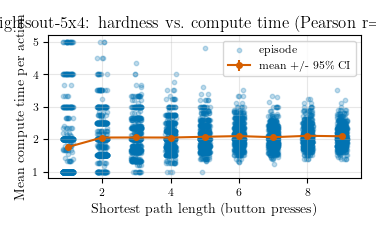

In [ ]:
CI95_Z = 1.96  # normal-approximation 95% CI half-width, in units of SEM

plot_df = df.dropna(subset=["shortest_path_length"])

pearson_r = plot_df["shortest_path_length"].corr(plot_df["compute_time"], method="pearson")
spearman_r = plot_df["shortest_path_length"].corr(plot_df["compute_time"], method="spearman")
print(f"Pearson r  = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}")

by_distance = plot_df.groupby("shortest_path_length")["compute_time"].agg(["mean", "sem", "count"])

fig, ax = plt.subplots(figsize=set_size(doc_width_pt, fraction=0.6))
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.15, 0.15, size=len(plot_df))
ax.scatter(
    plot_df["shortest_path_length"] + jitter,
    plot_df["compute_time"],
    s=10,
    alpha=0.25,
    color=sns.color_palette("colorblind")[0],
    label="episode",
)
ax.errorbar(
    by_distance.index,
    by_distance["mean"],
    yerr=CI95_Z * by_distance["sem"].fillna(0.0),
    marker="o",
    ms=4,
    linewidth=1.5,
    color=sns.color_palette("colorblind")[3],
    label=r"mean +/- 95\% CI",
)
ax.set_xlabel("Shortest path length (button presses)")
ax.set_ylabel("Mean compute time per action")
ax.set_title(f"lightsout-{GRID_SIZE}: hardness vs. compute time (Pearson r={pearson_r:.2f})")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.savefig("analysis-compute_time-hardness.pdf", dpi=600, format="pdf", bbox_inches="tight")

Pearson r  = 0.880
Spearman r = 0.869


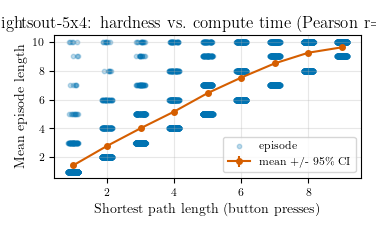

In [ ]:
CI95_Z = 1.96  # normal-approximation 95% CI half-width, in units of SEM

plot_df = df.dropna(subset=["shortest_path_length"])

pearson_r = plot_df["shortest_path_length"].corr(plot_df["episode_length"], method="pearson")
spearman_r = plot_df["shortest_path_length"].corr(plot_df["episode_length"], method="spearman")
print(f"Pearson r  = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}")

by_distance = plot_df.groupby("shortest_path_length")["episode_length"].agg(["mean", "sem", "count"])

fig, ax = plt.subplots(figsize=set_size(doc_width_pt, fraction=0.6))
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.15, 0.15, size=len(plot_df))
ax.scatter(
    plot_df["shortest_path_length"] + jitter,
    plot_df["episode_length"],
    s=10,
    alpha=0.25,
    color=sns.color_palette("colorblind")[0],
    label="episode",
)
ax.errorbar(
    by_distance.index,
    by_distance["mean"],
    yerr=CI95_Z * by_distance["sem"].fillna(0.0),
    marker="o",
    ms=4,
    linewidth=1.5,
    color=sns.color_palette("colorblind")[3],
    label=r"mean +/- 95\% CI",
)
ax.set_xlabel("Shortest path length (button presses)")
ax.set_ylabel("Mean episode length")
ax.set_title(f"lightsout-{GRID_SIZE}: hardness vs. compute time (Pearson r={pearson_r:.2f})")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.savefig("analysis-episode_length-hardness.pdf", dpi=600, format="pdf", bbox_inches="tight")

## Per-step compute time vs. remaining hardness

The two analyses above only look at each episode's *starting* hardness (shortest
path from the grid at reset to the goal). `rollout_episodes` also records every
step's own grid (`states`) and the actor's compute time *at that step*
(`compute_times`), padded to `ROLLOUT_MAX_STEPS` with a `valid_steps` mask marking
which entries are real (episodes that solve before truncating leave trailing
padding). This section drops the padding, recomputes the GF(2) shortest path from
each step's *current* grid to the goal, and checks whether compute time tracks the
puzzle's remaining difficulty as it's solved, rather than only its difficulty at
reset.

[per-step] Pearson r  = 0.095
[per-step] Spearman r = 0.180


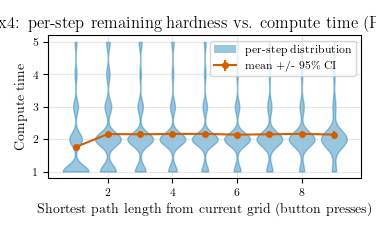

In [ ]:
def build_step_dataframe(df, gf2_prepared):
    """Expands each episode's padded-to-ROLLOUT_MAX_STEPS `states`/
    `compute_times` (see rollout_episodes) into one row per real step -
    dropping the trailing padding via `valid_steps` - and computes the
    shortest-path length from that step's *current* grid to the episode's
    goal grid."""
    rows = []
    for _, episode_row in df.iterrows():
        goal_grid = episode_row["goal_grid"]
        if not episode_row["solved"]:
            continue

        for step, (grid, compute_time, valid) in enumerate(
            zip(episode_row["states"], episode_row["compute_times"], episode_row["valid_steps"])
        ):
            if not valid:
                continue
            diff = np.logical_xor(grid, goal_grid).astype(np.uint8)
            rows.append(
                {
                    "episode": episode_row["episode"],
                    "step": step,
                    "compute_time": float(compute_time),
                    "shortest_path_length": gf2_min_weight_solution(gf2_prepared, diff),
                    "length_to_go": episode_row["episode_length"] - step,
                }
            )
    return pd.DataFrame.from_records(rows)


step_df = build_step_dataframe(df, gf2_prepared)
step_plot_df = step_df.dropna(subset=["shortest_path_length"])

step_pearson_r = step_plot_df["shortest_path_length"].corr(step_plot_df["compute_time"], method="pearson")
step_spearman_r = step_plot_df["shortest_path_length"].corr(step_plot_df["compute_time"], method="spearman")
print(f"[per-step] Pearson r  = {step_pearson_r:.3f}")
print(f"[per-step] Spearman r = {step_spearman_r:.3f}")

by_distance = step_plot_df.groupby("shortest_path_length")["compute_time"].agg(["mean", "sem", "count"])

# One violin per shortest-path-length value, positioned at its actual value on
# the x-axis (rather than seaborn's categorical slot-per-group placement) so it
# lines up with the mean +/- 95% CI overlay below without remapping. A KDE-based
# violin needs >= 2 distinct values, so groups that don't qualify (typically the
# sparsely-populated tails) fall back to being represented by that overlay alone.
violin_groups = [
    (distance, group["compute_time"].to_numpy())
    for distance, group in step_plot_df.groupby("shortest_path_length")
]
violin_groups = [(d, v) for d, v in violin_groups if len(v) >= 2 and np.std(v) > 0]
violin_color = sns.color_palette("colorblind")[0]
mean_color = sns.color_palette("colorblind")[3]

fig, ax = plt.subplots(figsize=set_size(doc_width_pt, fraction=0.6))
if violin_groups:
    parts = ax.violinplot(
        [v for _, v in violin_groups],
        positions=[d for d, _ in violin_groups],
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in parts["bodies"]:
        body.set_facecolor(violin_color)
        body.set_edgecolor(violin_color)
        body.set_alpha(0.4)

mean_errorbar = ax.errorbar(
    by_distance.index,
    by_distance["mean"],
    yerr=CI95_Z * by_distance["sem"].fillna(0.0),
    marker="o",
    ms=4,
    linewidth=1.5,
    color=mean_color,
    label=r"mean +/- 95\% CI",
)
ax.legend(
    handles=[Patch(facecolor=violin_color, alpha=0.4, label="per-step distribution"), mean_errorbar]
)
ax.set_xlabel("Shortest path length from current grid (button presses)")
ax.set_ylabel("Compute time")
ax.set_title(
    f"lightsout-{GRID_SIZE}: per-step remaining hardness vs. compute time "
    f"(Pearson r={step_pearson_r:.2f})"
)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("analysis-compute_time-hardness_per_step.pdf", dpi=600, format="pdf", bbox_inches="tight")

[per-step] Pearson r  = 0.904
[per-step] Spearman r = 0.924


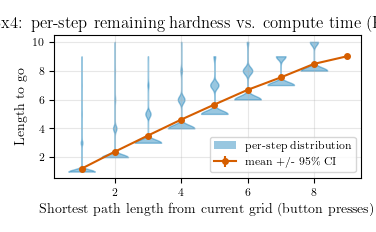

In [ ]:
step_pearson_r = step_plot_df["shortest_path_length"].corr(step_plot_df["length_to_go"], method="pearson")
step_spearman_r = step_plot_df["shortest_path_length"].corr(step_plot_df["length_to_go"], method="spearman")
print(f"[per-step] Pearson r  = {step_pearson_r:.3f}")
print(f"[per-step] Spearman r = {step_spearman_r:.3f}")

by_distance = step_plot_df.groupby("shortest_path_length")["length_to_go"].agg(["mean", "sem", "count"])

# One violin per shortest-path-length value, positioned at its actual value on
# the x-axis (rather than seaborn's categorical slot-per-group placement) so it
# lines up with the mean +/- 95% CI overlay below without remapping. A KDE-based
# violin needs >= 2 distinct values, so groups that don't qualify (typically the
# sparsely-populated tails) fall back to being represented by that overlay alone.
violin_groups = [
    (distance, group["length_to_go"].to_numpy())
    for distance, group in step_plot_df.groupby("shortest_path_length")
]
violin_groups = [(d, v) for d, v in violin_groups if len(v) >= 2 and np.std(v) > 0]
violin_color = sns.color_palette("colorblind")[0]
mean_color = sns.color_palette("colorblind")[3]

fig, ax = plt.subplots(figsize=set_size(doc_width_pt, fraction=0.6))
if violin_groups:
    parts = ax.violinplot(
        [v for _, v in violin_groups],
        positions=[d for d, _ in violin_groups],
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in parts["bodies"]:
        body.set_facecolor(violin_color)
        body.set_edgecolor(violin_color)
        body.set_alpha(0.4)

mean_errorbar = ax.errorbar(
    by_distance.index,
    by_distance["mean"],
    yerr=CI95_Z * by_distance["sem"].fillna(0.0),
    marker="o",
    ms=4,
    linewidth=1.5,
    color=mean_color,
    label=r"mean +/- 95\% CI",
)
ax.legend(
    handles=[Patch(facecolor=violin_color, alpha=0.4, label="per-step distribution"), mean_errorbar]
)
ax.set_xlabel("Shortest path length from current grid (button presses)")
ax.set_ylabel("Length to go")
ax.set_title(
    f"lightsout-{GRID_SIZE}: per-step remaining hardness vs. compute time "
    f"(Pearson r={step_pearson_r:.2f})"
)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("analysis-length_to_go-hardness_per_step.pdf", dpi=600, format="pdf", bbox_inches="tight")